<a href="https://colab.research.google.com/github/arun21733/climate-change/blob/main/milestone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle
import sys
import pandas as pd
import numpy as np
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Environment ready ✓")
print(f"Python version: {sys.version.split('|')[0]}")
print(f"Pandas version: {pd.__version__}")

Environment ready ✓
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Pandas version: 2.2.2


In [ ]:
#Upload kaggle.json file
from google.colab import files
uploaded = files.upload()

Saving kaggle (1).json to kaggle (1).json


In [ ]:
pip install opendatasets


In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository")

Skipping, found downloaded files in "./global-weather-repository" (use force=True to force download)


In [ ]:
print("\nData types:")
print(df.dtypes)


Data types:
country                          object
location_name                    object
latitude                        float64
longitude                       float64
timezone                         object
last_updated_epoch                int64
last_updated                     object
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                   

In [ ]:
print("\nFirst 3 rows:")
display(df.head(3))


First 3 rows:


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [ ]:
print("\nSample date range:")
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
print(df['last_updated'].agg(['min','max']))


Sample date range:
min   2024-05-16 01:45:00
max   2026-03-09 19:00:00
Name: last_updated, dtype: datetime64[ns]


In [ ]:
key_vars = [
    'temperature_celsius', 'feels_like_celsius',
    'humidity', 'precip_mm', 'wind_kph',
    'pressure_mb', 'uv_index', 'cloud',
    'gust_kph']

print("\nSummary statistics of key weather variables:")
display(df[key_vars].describe().round(2))

print("\nMissing values (absolute + %):")
missing = pd.DataFrame({
    'Missing': df.isnull().sum(),
    '% Missing': (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing[missing['Missing'] > 0])


Summary statistics of key weather variables:


,temperature_celsius,feels_like_celsius,humidity,precip_mm,wind_kph,pressure_mb,uv_index,cloud,gust_kph
count,128443.00,128443.00,128443.00,128443.00,128443.00,128443.00,128443.00,128443.0,128443.00
mean,21.46,22.33,66.33,0.14,12.96,1014.09,3.40,40.0,18.30
std,9.67,11.56,24.01,0.57,11.78,10.53,3.56,34.1,13.95
min,-29.80,-36.70,2.00,0.00,3.60,947.00,0.00,0.0,3.60
25%,16.20,16.20,50.00,0.00,6.10,1010.00,0.10,0.0,10.30
50%,24.10,25.30,72.00,0.00,11.20,1014.00,2.00,30.0,15.40
75%,28.00,30.00,85.00,0.03,17.60,1018.00,6.00,75.0,24.30
max,49.20,51.20,100.00,42.24,2963.20,3006.00,16.30,100.0,2970.40



Missing values (absolute + %):


,Missing,% Missing


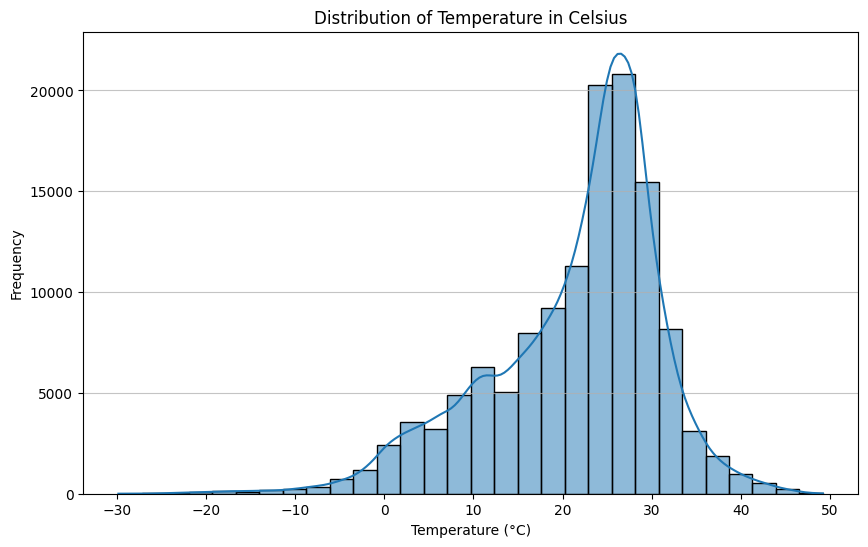

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['temperature_celsius'], kde=True, bins=30)
plt.title('Distribution of Temperature in Celsius')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
# 1. Datetime
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')
print(df)

            country     location_name  latitude  longitude         timezone  \
0       Afghanistan             Kabul   34.5200    69.1800       Asia/Kabul   
1           Albania            Tirana   41.3300    19.8200    Europe/Tirane   
2           Algeria           Algiers   36.7600     3.0500   Africa/Algiers   
3           Andorra  Andorra La Vella   42.5000     1.5200   Europe/Andorra   
4            Angola            Luanda   -8.8400    13.2300    Africa/Luanda   
...             ...               ...       ...        ...              ...   
128438      Vanuatu         Port Vila  -17.7333   168.3167    Pacific/Efate   
128439    Venezuela           Caracas   10.5000   -66.9167  America/Caracas   
128440      Vietnam             Hanoi   21.0333   105.8500     Asia/Bangkok   
128441        Yemen             Sanaa   15.3547    44.2067        Asia/Aden   
128442     Zimbabwe            Harare  -17.8178    31.0447    Africa/Harare   

        last_updated_epoch        last_updated  tem

In [ ]:
# 2. Clip physically impossible values
df['humidity'] = df['humidity'].clip(0, 100)
df['precip_mm']  = df['precip_mm'].clip(lower=0)
df['wind_kph']   = df['wind_kph'].clip(lower=0)
df['gust_kph']   = df['gust_kph'].clip(lower=0)
print (df)

            country     location_name  latitude  longitude         timezone  \
0       Afghanistan             Kabul   34.5200    69.1800       Asia/Kabul   
1           Albania            Tirana   41.3300    19.8200    Europe/Tirane   
2           Algeria           Algiers   36.7600     3.0500   Africa/Algiers   
3           Andorra  Andorra La Vella   42.5000     1.5200   Europe/Andorra   
4            Angola            Luanda   -8.8400    13.2300    Africa/Luanda   
...             ...               ...       ...        ...              ...   
128438      Vanuatu         Port Vila  -17.7333   168.3167    Pacific/Efate   
128439    Venezuela           Caracas   10.5000   -66.9167  America/Caracas   
128440      Vietnam             Hanoi   21.0333   105.8500     Asia/Bangkok   
128441        Yemen             Sanaa   15.3547    44.2067        Asia/Aden   
128442     Zimbabwe            Harare  -17.8178    31.0447    Africa/Harare   

        last_updated_epoch        last_updated  tem

In [ ]:
# 3. Fill missing values (simple strategy – forward fill per location + global median fallback)
df_clean = df.copy()
df_clean = df_clean.sort_values(['location_name', 'last_updated'])

for col in key_vars:
    # forward fill within same location
    df_clean[col] = df_clean.groupby('location_name')[col].ffill()
    # then fill remaining with global median
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
print (df_clean)

        country      location_name  latitude  longitude         timezone  \
3265    Belgium  'S Gravenjansdijk     51.25       3.63  Europe/Brussels   
3460    Belgium  'S Gravenjansdijk     51.25       3.63  Europe/Brussels   
4045    Belgium  'S Gravenjansdijk     51.25       3.63  Europe/Brussels   
4240    Belgium  'S Gravenjansdijk     51.25       3.63  Europe/Brussels   
5408    Belgium  'S Gravenjansdijk     51.25       3.63  Europe/Brussels   
...         ...                ...       ...        ...              ...   
127297  Croatia             Zagreb     45.80      16.00    Europe/Zagreb   
127492  Croatia             Zagreb     45.80      16.00    Europe/Zagreb   
127687  Croatia             Zagreb     45.80      16.00    Europe/Zagreb   
127882  Croatia             Zagreb     45.80      16.00    Europe/Zagreb   
128077  Croatia             Zagreb     45.80      16.00    Europe/Zagreb   

        last_updated_epoch        last_updated  temperature_celsius  \
3265            

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for columns with missing values
missing_data_to_plot = missing[missing['Missing'] > 0]

if not missing_data_to_plot.empty:
    plt.figure(figsize=(12, 7))
    sns.barplot(x=missing_data_to_plot.index, y='Missing', data=missing_data_to_plot, palette='viridis')
    plt.title('Count of Missing Values per Column')
    plt.xlabel('Column Name')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the dataset to plot.')

No missing values found in the dataset to plot.


### How to Upload Your Colab Notebook to GitHub

There are a few ways to get your Colab notebook onto GitHub. Here's a common method:

#### Method 1: Using Colab's Built-in GitHub Integration

1.  **Save a Copy to GitHub**: Go to `File > Save a copy in GitHub...`.
2.  **Authenticate**: Colab will ask you to authenticate with your GitHub account.
3.  **Choose Repository**: Select an existing repository or create a new one.
4.  **Commit Message**: Add a descriptive commit message.
5.  **Save**: Click OK to save your notebook directly to your GitHub repository.

#### Method 2: Manual Upload (if you prefer more control or want to use Git locally)

1.  **Download your Notebook**: Go to `File > Download > Download .ipynb`.
2.  **Create a GitHub Repository**:
    *   Go to [GitHub](https://github.com/).
    *   Click the '+' sign in the top right corner and select 'New repository'.
    *   Give your repository a name, an optional description, and choose if it's public or private. You can also initialize it with a README, .gitignore, and license (though for just uploading a notebook, this is optional).
    *   Click 'Create repository'.
3.  **Upload the Notebook to GitHub (via browser)**:
    *   On your new GitHub repository page, click the 'Add file' dropdown and select 'Upload files'.
    *   Drag and drop your downloaded `.ipynb` file onto the page, or click 'choose your files'.
    *   Add a commit message (e.g., "Add initial Colab notebook").
    *   Click 'Commit changes'.

#### Method 3: Using Git on your Local Machine (more advanced, for version control)

If you have Git installed locally and want to manage version control more robustly, you can:

1.  **Download your Notebook**: Go to `File > Download > Download .ipynb`.
2.  **Initialize a Local Git Repository** (if not already in one):
    ```bash
    cd /path/to/your/project/folder
    git init
    ```
3.  **Add your Notebook**:
    ```bash
    git add your_notebook_name.ipynb
    ```
4.  **Commit your Changes**:
    ```bash
    git commit -m "Add initial Colab notebook"
    ```
5.  **Connect to GitHub Repository**: (Assuming you've created an empty repository on GitHub as in Method 2)
    ```bash
    git remote add origin https://github.com/your-username/your-repo-name.git
    ```
    (Replace `your-username` and `your-repo-name` with your actual details.)
6.  **Push to GitHub**:
    ```bash
    git push -u origin master # or main, depending on your default branch name
    ```

### How to Share with Your Group

Once your notebook is on GitHub, sharing is easy:

1.  **Get the Repository Link**: Navigate to your repository on GitHub. The URL in your browser's address bar is the link you can share (e.g., `https://github.com/your-username/your-repo-name`).
2.  **Provide Collaborator Access (Optional)**: If you want your group members to be able to directly contribute (push changes) to your repository, you can add them as collaborators:
    *   Go to your repository on GitHub.
    *   Click on 'Settings'.
    *   Click on 'Collaborators and teams' in the left sidebar.
    *   Click 'Add collaborator' and enter their GitHub username or email address.

In [ ]:
print("\nMissing values after cleaning:", df_clean[key_vars].isnull().sum().sum())


Missing values after cleaning: 0


In [ ]:
# Add year-month column
df_clean['year_month'] = df_clean['last_updated'].dt.to_period('M')
# Group by location + month
monthly = df_clean.groupby(['country', 'location_name', 'latitude', 'longitude', 'year_month'])[key_vars].mean().reset_index()

# Convert period back to date (first day of month)
monthly['date'] = monthly['year_month'].dt.to_timestamp()

monthly = monthly.drop(columns=['year_month'])

print("\nMonthly aggregated shape:", monthly.shape)
display(monthly.head(8))


Monthly aggregated shape: (4772, 14)


,country,location_name,latitude,longitude,temperature_celsius,feels_like_celsius,humidity,precip_mm,wind_kph,pressure_mb,uv_index,cloud,gust_kph,date
0,Afghanistan,Kabul,34.5167,69.1833,21.696552,21.427586,22.344828,0.108621,6.472414,1012.172414,3.989655,14.172414,7.724138,2024-10-01
1,Afghanistan,Kabul,34.5167,69.1833,15.670000,15.656667,27.466667,0.002000,4.646667,1015.900000,2.760000,19.666667,7.743333,2024-11-01
2,Afghanistan,Kabul,34.5167,69.1833,7.174194,6.922581,22.387097,0.000323,4.235484,1018.322581,0.632258,14.645161,8.522581,2024-12-01
3,Afghanistan,Kabul,34.5167,69.1833,1.312903,-0.638710,58.870968,0.074516,6.961290,1022.806452,0.854839,36.096774,9.280645,2025-01-01
4,Afghanistan,Kabul,34.5167,69.1833,4.789286,3.317857,47.857143,0.050714,7.139286,1019.321429,1.650000,29.250000,9.150000,2025-02-01
5,Afghanistan,Kabul,34.5167,69.1833,11.993548,11.487097,33.032258,0.063871,6.322581,1015.258065,3.558065,18.903226,9.645161,2025-03-01
6,Afghanistan,Kabul,34.5167,69.1833,22.986667,22.366667,18.400000,0.001333,6.613333,1010.200000,7.653333,19.433333,9.156667,2025-04-01
7,Afghanistan,Kabul,34.5167,69.1833,27.267742,25.780645,17.483871,0.140323,10.783871,1005.806452,9.390323,21.516129,12.622581,2025-05-01


In [ ]:
os.makedirs("processed", exist_ok=True)
# Save monthly version (recommended for analysis & viz)
monthly.to_csv("processed/global_weather_monthly.csv", index=False)
print("\nSaved: processed/global_weather_monthly.csv")

# Optional: also save cleaned daily version
# df_clean.to_csv("processed/global_weather_cleaned_daily.csv", index=False)
# print("Saved: processed/global_weather_cleaned_daily.csv")


Saved: processed/global_weather_monthly.csv


In [ ]:
print("""
Milestone 1 – Summary Document (copy this text into your report)

Data Schema (main columns used):
- country, location_name, latitude, longitude
- last_updated / date (datetime)
- temperature_celsius, feels_like_celsius
- humidity (%), precip_mm, wind_kph, pressure_mb, uv_index, cloud, gust_kph

Key Variables:
temperature_celsius, humidity, precip_mm, wind_kph → core for trends & extremes

Data Quality Issues & Resolutions:
• Missing values: originally present in some weather metrics → filled using location-wise forward-fill + global median
• Anomalies: humidity >100 or <0, negative precipitation/wind → clipped to realistic range
• Units: already mostly metric (°C, mm, kph, mb) → no major conversion needed
• Coverage: capital cities worldwide, daily since ~2023
• Final format: monthly averages per location (much smaller, suitable for visualization & analysis)

Deliverable files created:
→ processed/global_weather_monthly.csv   ← recommended for Milestone 2+

Success: Dataset cleaned, aggregated and ready for analysis ✓
""")


Milestone 1 – Summary Document (copy this text into your report)

Data Schema (main columns used):
- country, location_name, latitude, longitude
- last_updated / date (datetime)
- temperature_celsius, feels_like_celsius
- humidity (%), precip_mm, wind_kph, pressure_mb, uv_index, cloud, gust_kph

Key Variables:
temperature_celsius, humidity, precip_mm, wind_kph → core for trends & extremes

Data Quality Issues & Resolutions:
• Missing values: originally present in some weather metrics → filled using location-wise forward-fill + global median
• Anomalies: humidity >100 or <0, negative precipitation/wind → clipped to realistic range
• Units: already mostly metric (°C, mm, kph, mb) → no major conversion needed
• Coverage: capital cities worldwide, daily since ~2023
• Final format: monthly averages per location (much smaller, suitable for visualization & analysis)

Deliverable files created:
→ processed/global_weather_monthly.csv   ← recommended for Milestone 2+

Success: Dataset cleaned, 